In [ ]:
#Pacotes necessários para a análise
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score, recall_score



In [ ]:

# 1. Leitura e preparação dos dados
df = pd.read_csv("../data/data-heart-disease.csv")
df.drop(columns=["id"], inplace=True, errors='ignore')


In [ ]:
# analise estatística básica
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.00000,270000.000000
mean,54.159870,0.716315,3.315107,130.555089,245.045270,0.080052,0.978493,152.783756,0.274656,0.718082,1.459356,0.45480,4.619774
std,8.255471,0.450787,0.851762,15.007908,33.695458,0.271374,0.998686,19.153454,0.446341,0.947417,0.546186,0.80127,1.950273
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.00000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.00000,3.000000
50%,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.00000,3.000000
75%,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.00000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.00000,7.000000


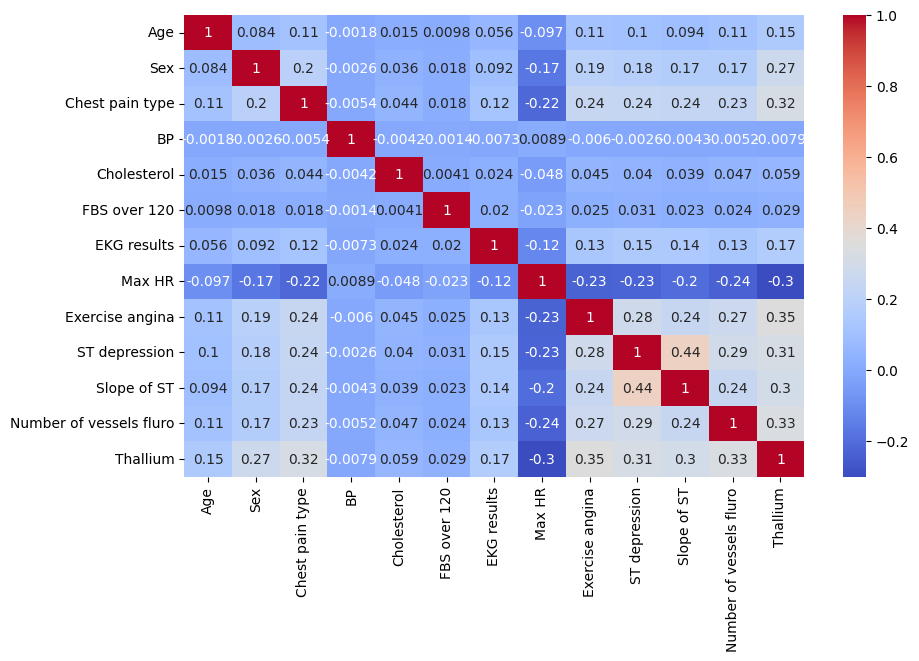

In [ ]:
# Heatmap para visualizar correlações entre as variáveis numéricas
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:

# Definindo as categorias do dataset
col_cat = ["Chest pain type", "EKG results", "Slope of ST", "Thallium", "Number of vessels fluro"]
col_num = ["Age", "BP", "Cholesterol", "Max HR", "ST depression"]
col_bin = ["Sex", "FBS over 120", "Exercise angina"]

# Separando em treino e teste
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train = df_train.copy()
df_test = df_test.copy()

# Pipeline de Pré-processamento
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), col_num),
    ("cat", OneHotEncoder(handle_unknown='ignore'), col_cat),
    ("bin", "passthrough", col_bin)
])
# Aplicando a normalização e codificação e PCA
X_train_proc = preprocessor.fit_transform(df_train)
X_test_proc = preprocessor.transform(df_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_proc)
X_test_pca = pca.transform(X_test_proc)


# Separando em clusters usando K-Means e Isolation Forest


# K-Means
km = KMeans(n_clusters=2, n_init=20, random_state=42)
df_train['risco_km'] = km.fit_predict(X_train_pca)
df_test['risco_km'] = km.predict(X_test_pca)

# Isolation Forest
iso = IsolationForest(contamination=0.15, random_state=42)
df_train['risco_iso'] = np.where(iso.fit_predict(X_train_pca) == -1, 1, 0)
df_test['risco_iso'] = np.where(iso.predict(X_test_pca) == -1, 1, 0)



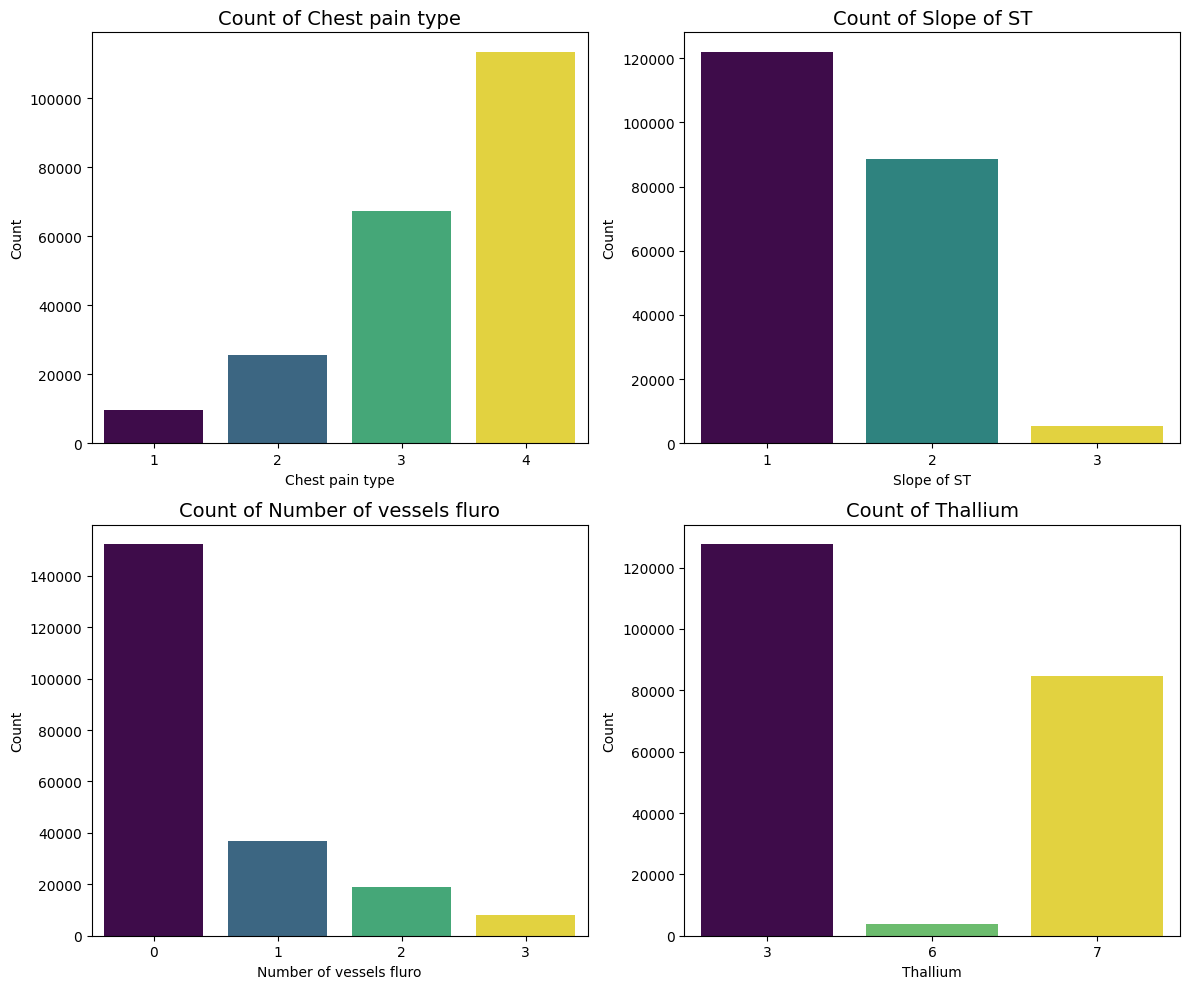

In [ ]:

# Plot da col_numontagem das variáveis categóricas antes da geração dos clusters
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.subplots_adjust(hspace=0.4)

variables = ["Chest pain type", "Slope of ST", "Number of vessels fluro", "Thallium"]

for i, var in enumerate(variables):
    ax = axes[i // 2, i % 2]
    # Added hue=var and legend=False to address the FutureWarning
    sns.countplot(x=var, data=df_train, ax=ax, palette="viridis", hue=var, legend=False)
    ax.set_title(f"Count of {var}", fontsize=14)
    ax.set_xlabel(var)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

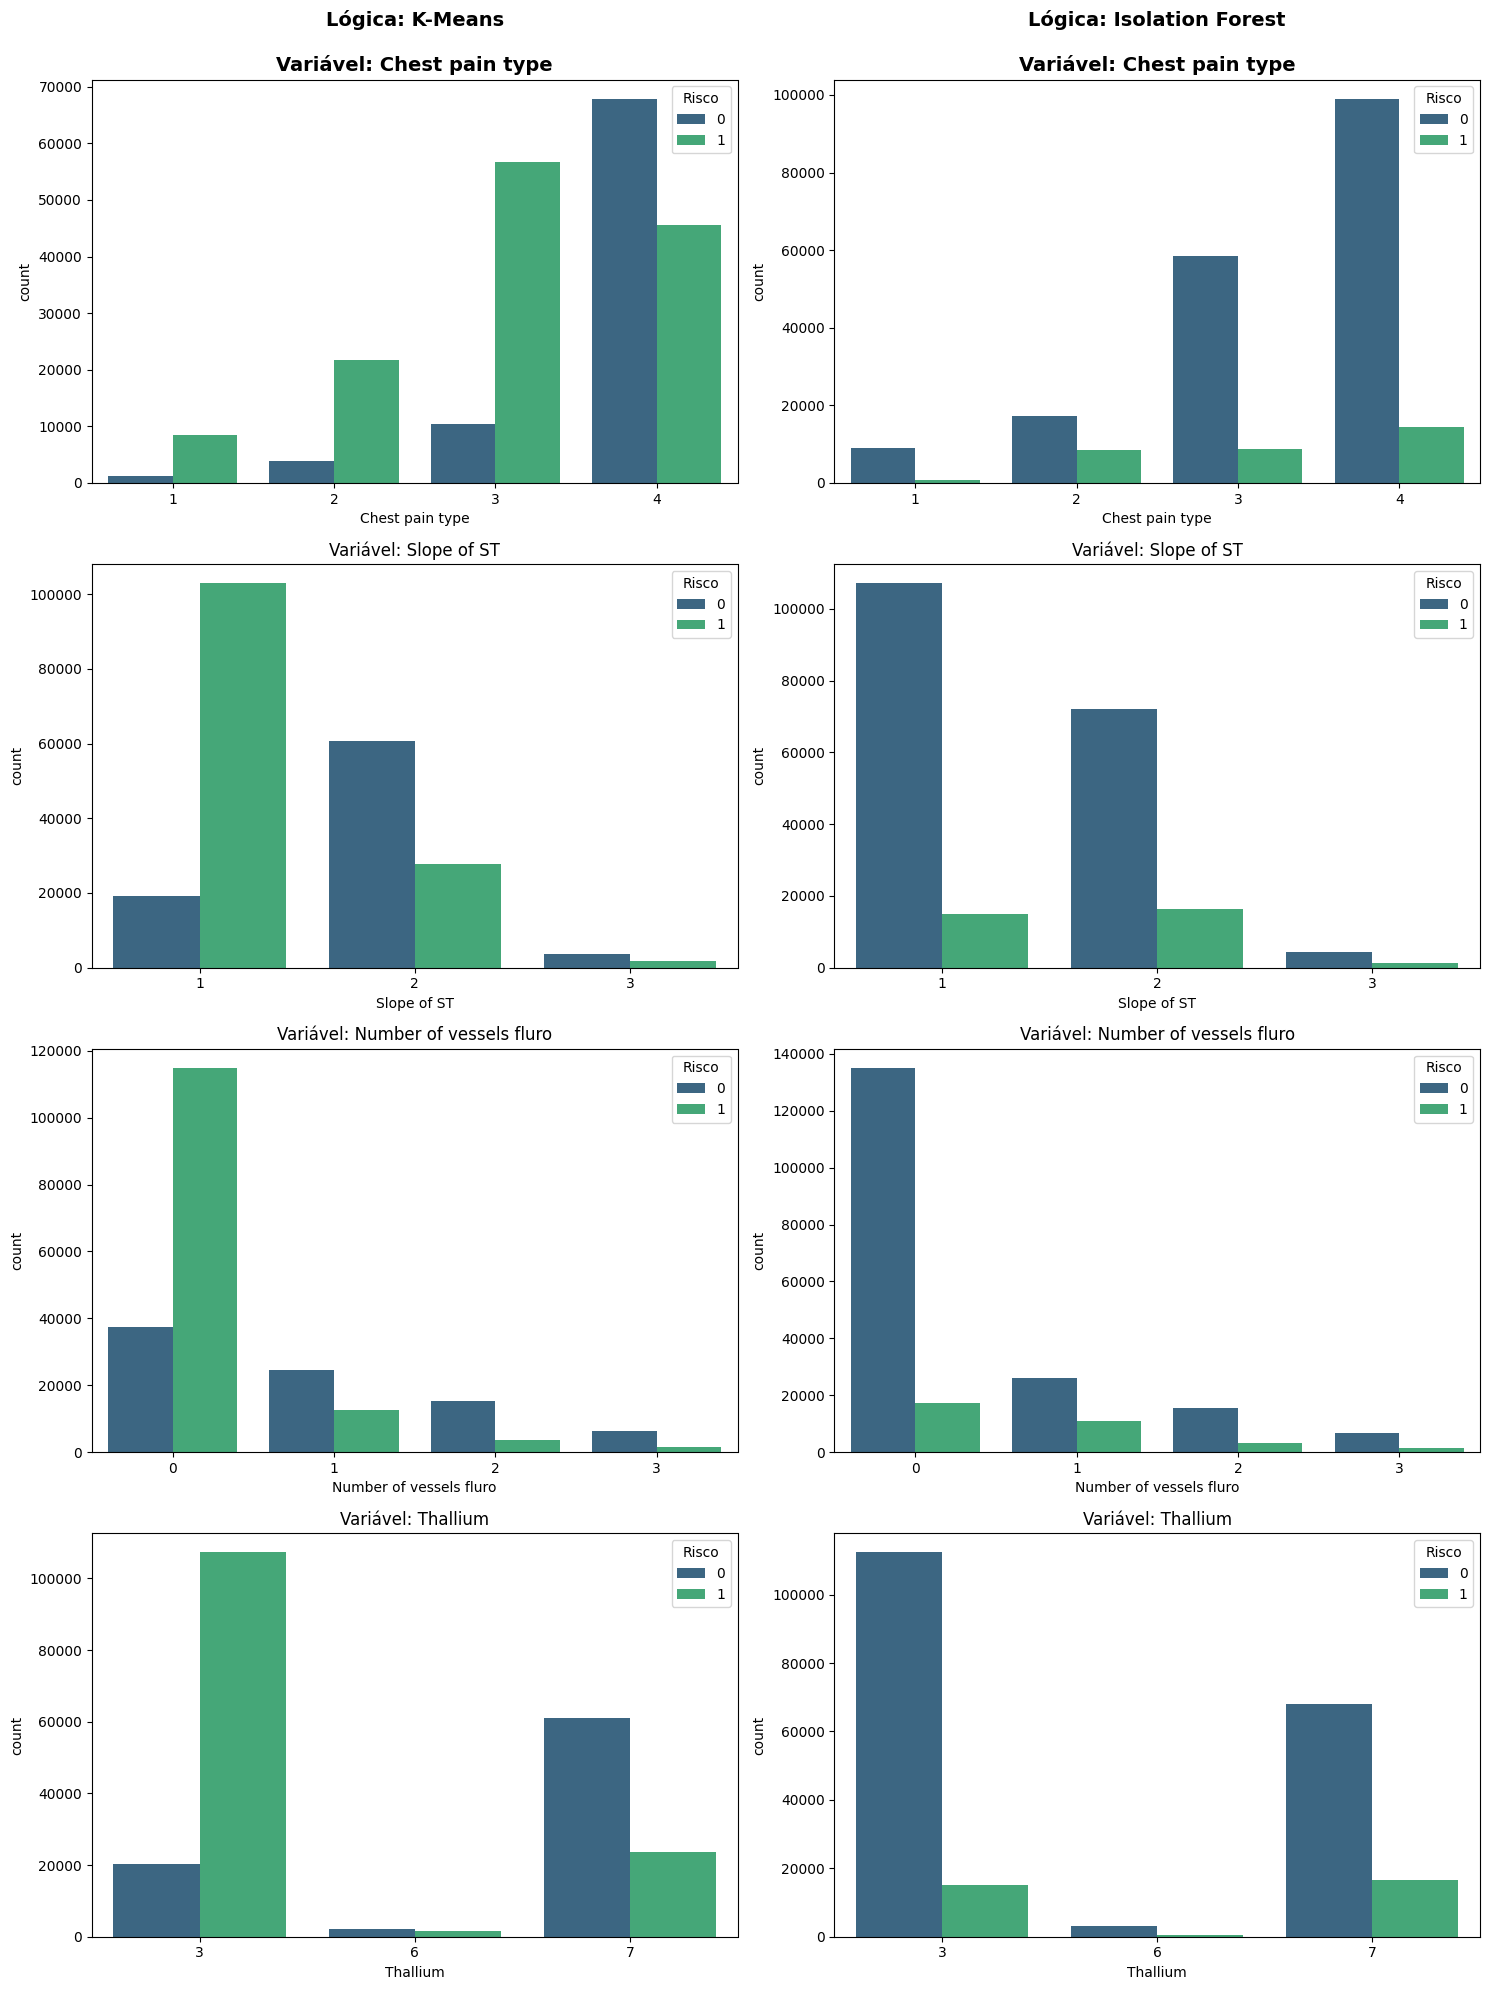

In [ ]:
# Plot comparativo entre os clusters gerados pelos modelos e as variáveis categóricas
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
plt.subplots_adjust(hspace=0.4)

# Lista de variáveis para iterar
variaveis = ["Chest pain type", "Slope of ST", "Number of vessels fluro", "Thallium"]
modelos_label = ["risco_km", "risco_iso"]
titulos_modelos = ["K-Means", "Isolation Forest"]

for i, var in enumerate(variaveis):
    for j, mod in enumerate(modelos_label):
        ax = axes[i, j]
        
        # Se a variável for ST depression (contínua), usamos Boxplot
        if var == "ST depression":
            sns.boxplot(x=mod, y=var, data=df_train, ax=ax, palette="Set2")
        
        # Para as outras (que são ordinais/categóricas), usamos Countplot para ver a distribuição
        else:
            # Mostra a proporção de cada categoria dentro do cluster/anomalia
            sns.countplot(x=var, hue=mod, data=df_train, ax=ax, palette="viridis")
            ax.legend(title="Risco", loc='upper right')

        # Títulos
        if i == 0:
            ax.set_title(f"Lógica: {titulos_modelos[j]}\n\nVariável: {var}", fontsize=14, fontweight='bold')
        else:
            ax.set_title(f"Variável: {var}", fontsize=12)

plt.tight_layout()
plt.show()

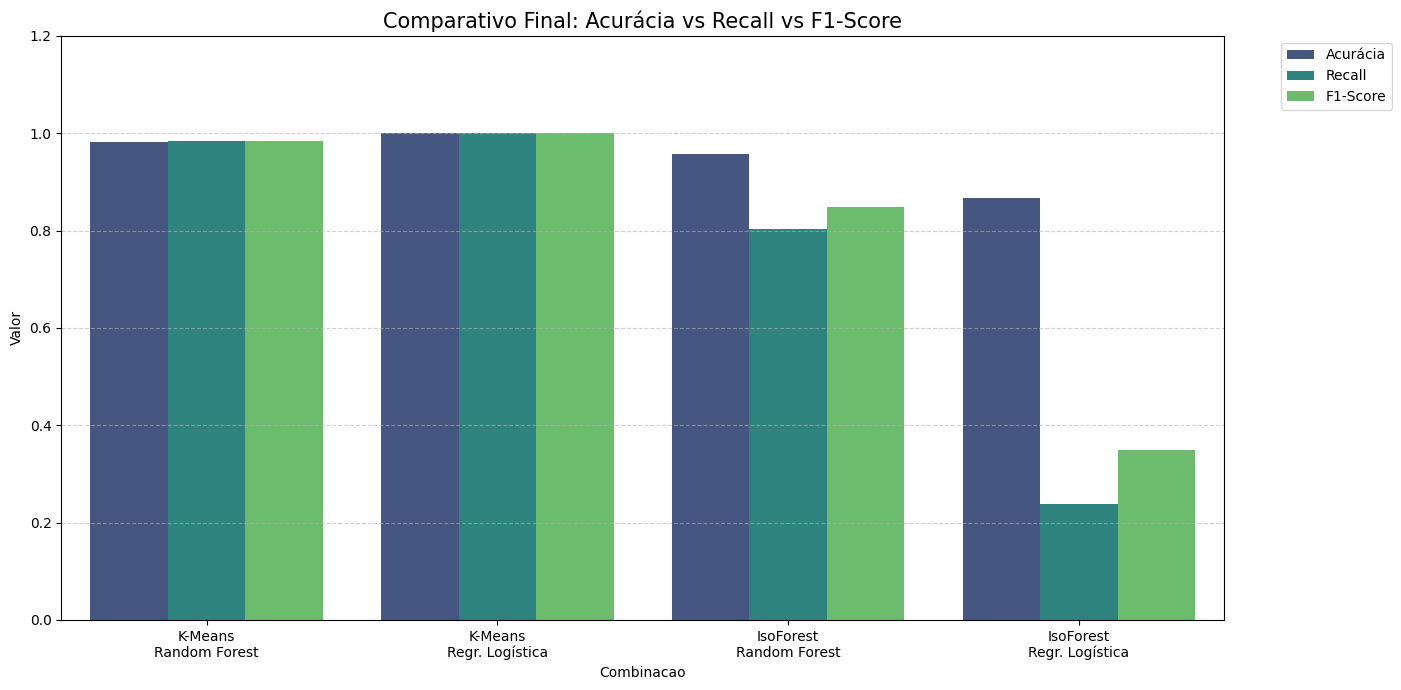


--- TABELA DE RESULTADOS COMPLETA ---
Metodo_Label   Classificador  Acurácia   Recall  F1-Score
     K-Means Regr. Logística  0.999556 0.999610  0.999640
     K-Means   Random Forest  0.981093 0.984026  0.984662
   IsoForest   Random Forest  0.956944 0.803042  0.848188
   IsoForest Regr. Logística  0.867093 0.237265  0.348434


In [ ]:




# Comparativo entre os classificadores Random Forest e Regressão Logística usando as colunas de risco geradas pelos modelos de clusterização
metodos = {
    "K-Means": ("risco_km"),
    "IsoForest": ("risco_iso")
}

classificadores = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Regr. Logística": LogisticRegression(max_iter=1000)
}

resultados = []

for nome_metodo, coluna_alvo in metodos.items():
    for nome_clf, clf in classificadores.items():
        # Seleção dos alvos
        y_train = df_train[coluna_alvo]
        y_test = df_test[coluna_alvo]
        
        # Treino
        X_train = df_train.drop(columns=['risco_km', 'risco_iso'])
        X_test = df_test.drop(columns=['risco_km', 'risco_iso'])
        
        pipe = Pipeline([('pre', preprocessor), ('model', clf)])
        pipe.fit(X_train, y_train)
        
        y_pred = pipe.predict(X_test)
        
        # Cálculo das Métricas
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred) # <--- NOVO
        
        resultados.append({
            "Metodo_Label": nome_metodo,
            "Classificador": nome_clf,
            "Acurácia": acc,
            "Recall": rec, # <--- NOVO
            "F1-Score": f1,
            "Combinacao": f"{nome_metodo}\n{nome_clf}"
        })

df_res = pd.DataFrame(resultados)



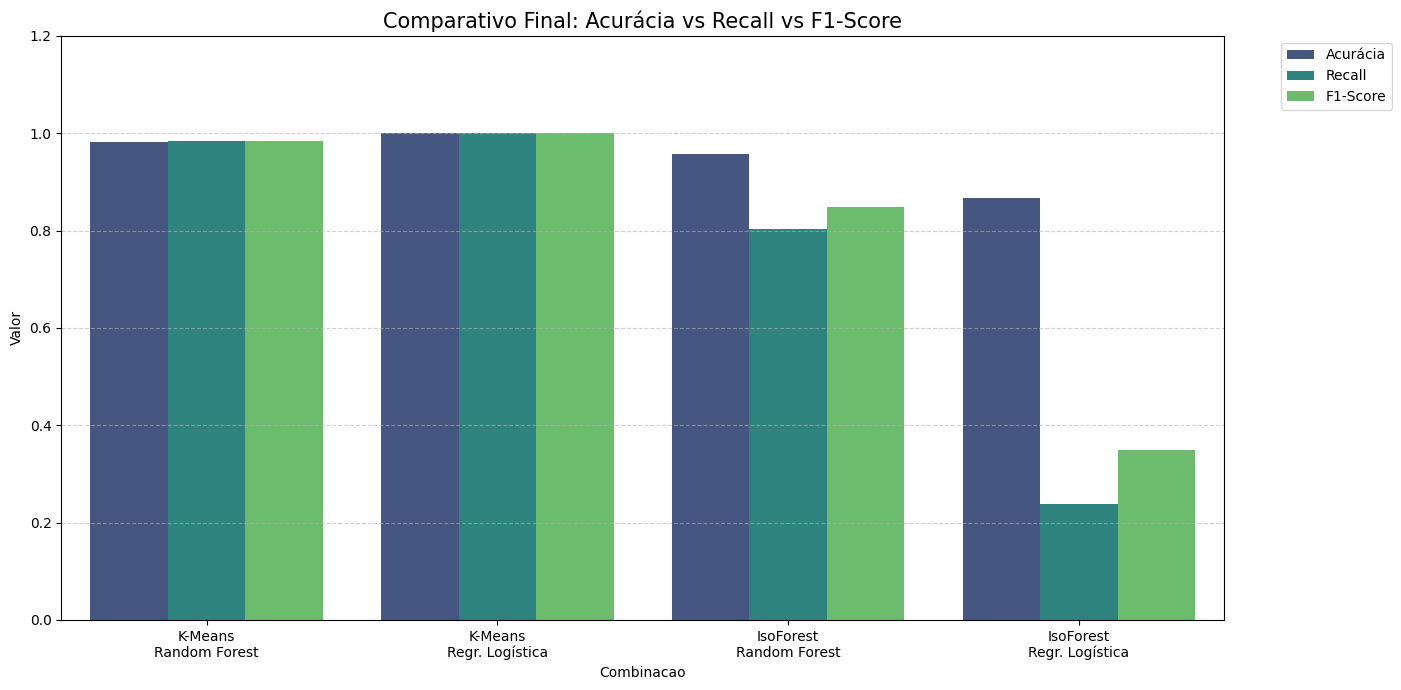


--- TABELA DE RESULTADOS COMPLETA ---
Metodo_Label   Classificador  Acurácia   Recall  F1-Score
     K-Means Regr. Logística  0.999556 0.999610  0.999640
     K-Means   Random Forest  0.981093 0.984026  0.984662
   IsoForest   Random Forest  0.956944 0.803042  0.848188
   IsoForest Regr. Logística  0.867093 0.237265  0.348434


In [ ]:
# Grafico de barras comparativo entre os modelos e as métricas
df_plot = df_res.melt(id_vars="Combinacao", value_vars=["Acurácia", "Recall", "F1-Score"], 
                      var_name="Métrica", value_name="Valor")

plt.figure(figsize=(14, 7))
sns.barplot(data=df_plot, x="Combinacao", y="Valor", hue="Métrica", palette="viridis")
plt.title("Comparativo Final: Acurácia vs Recall vs F1-Score", fontsize=15)
plt.ylim(0, 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

# --- EXIBIÇÃO DA TABELA FINAL ---
print("\n--- TABELA DE RESULTADOS COMPLETA ---")
print(df_res[["Metodo_Label", "Classificador", "Acurácia", "Recall", "F1-Score"]]
      .sort_values(by="F1-Score", ascending=False)
      .to_string(index=False))

In [ ]:
# Analise de importância das variáveis para cada modelo e método
importancias_gerais = []

for nome_metodo, coluna_alvo in metodos.items():
    for nome_clf, clf in classificadores.items():
        
        # Re-treinamos o pipe para garantir que estamos acessando o modelo ajustado
        X_train = df_train.drop(columns=['risco_km', 'risco_iso'])
        y_train = df_train[coluna_alvo]
        
        pipe = Pipeline([('pre', preprocessor), ('model', clf)])
        pipe.fit(X_train, y_train)
        
        # 1. Extrair nomes das colunas após o processamento (OneHotEncoder gera novas colunas)
        # O preprocessor guardou a ordem das colunas
        features_names = pipe.named_steps['pre'].get_feature_names_out()
        
        # 2. Extrair pesos/importâncias
        if nome_clf == "Random Forest":
            pesos = pipe.named_steps['model'].feature_importances_
        else:
            # Para Logística, pegamos o valor absoluto dos coeficientes
            pesos = np.abs(pipe.named_steps['model'].coef_[0])
            # Normalizamos para facilitar a leitura (0 a 1)
            pesos = pesos / np.sum(pesos)
            
        # 3. Criar um DataFrame temporário para ordenar
        df_imp = pd.DataFrame({'Feature': features_names, 'Importance': pesos})
        top_5 = df_imp.sort_values(by='Importance', ascending=False).head(5)
        
        # Guardar no formato para exibição
        for _, row in top_5.iterrows():
            importancias_gerais.append({
                "Abordagem": nome_metodo,
                "Modelo": nome_clf,
                "Variável": row['Feature'],
                "Importância": round(row['Importance'], 4)
            })


df_final_imp = pd.DataFrame(importancias_gerais)

print("\n--- TOP 5 VARIÁVEIS POR MODELO E MÉTODO ---")
for grupo, dados in df_final_imp.groupby(['Abordagem', 'Modelo']):
    print(f"\nCombo: {grupo[0]} + {grupo[1]}")
    print(dados[['Variável', 'Importância']].to_string(index=False))


--- TOP 5 VARIÁVEIS POR MODELO E MÉTODO ---

Combo: IsoForest + Random Forest
          Variável  Importância
       num__Max HR       0.1432
num__ST depression       0.1324
  num__Cholesterol       0.1104
           num__BP       0.0939
          num__Age       0.0845

Combo: IsoForest + Regr. Logística
                      Variável  Importância
        cat__Chest pain type_2       0.1319
                      bin__Sex       0.1299
          bin__Exercise angina       0.1155
        cat__Chest pain type_4       0.1083
cat__Number of vessels fluro_1       0.0706

Combo: K-Means + Random Forest
          Variável  Importância
num__ST depression       0.2716
       num__Max HR       0.1763
   cat__Thallium_3       0.1154
cat__Slope of ST_1       0.0824
   cat__Thallium_7       0.0614

Combo: K-Means + Regr. Logística
          Variável  Importância
num__ST depression       0.1565
       num__Max HR       0.1275
   cat__Thallium_3       0.0761
cat__Slope of ST_1       0.0740
          n